In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from pathlib import Path
import pandas as pd
import seaborn as sns

q = pd.read_csv("../results/kamervragen_annotated_q_v0.7.csv", sep="\t")
a = pd.read_csv("../results/kamervragen_annotated_a_v0.3.csv", sep="\t")

# Keep only annotation columns from answers file
a_ann = a[["src_id", "vraag_nr", "llm_label", "llm_confidence", "llm_reasoning"]]

df = q.rename(columns={
    "llm_label":      "q_label",
    "llm_confidence": "q_confidence",
    "llm_reasoning":  "q_reasoning",
}).merge(
    a_ann.rename(columns={
        "llm_label":      "a_label",
        "llm_confidence": "a_confidence",
        "llm_reasoning":  "a_reasoning",
    }),
    on=["src_id", "vraag_nr"],
    how="left",  # keep all questions; a_label NaN where answer was too short
)

# EDA Words

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd
import spacy

dft = df.copy()
# dft = dft.dropna(subset='llm_b_label')
# dft['llm_b_label'] = dft.llm_modifiers.str.split(',')
# dft = dft.explode(column='llm_modifiers')

# Load Dutch spaCy model
nlp = spacy.load("nl_core_news_sm")

# Function to extract only adjectives (or verbs if you prefer)
def extract_adjs(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc if token.pos_ == 'VERB'])

# Clean 'vraag' column and extract adjectives
dft['vraag'] = dft['vraag'].fillna('').str.lower()
dft['vraag_adjs'] = dft['vraag'].apply(extract_adjs)

# Concatenate texts per label
label_texts = dft.groupby('a_label')['vraag_adjs'].apply(lambda x: ' '.join(x)).to_dict()
labels = list(label_texts.keys())
texts = [label_texts[label] for label in labels]

# Build full vocabulary first
vectorizer = CountVectorizer()  # no min_df
X_full = vectorizer.fit_transform(texts)
vocab = np.array(vectorizer.get_feature_names_out())

# Apply minimum **overall frequency** filter
min_count = 10  # minimum number of occurrences across all labels
token_counts = X_full.sum(axis=0).A1  # total counts per token
mask = token_counts >= min_count
vocab_filtered = vocab[mask]
X_filtered = X_full[:, mask]

# Total tokens per label (for relative freq)
label_totals = X_filtered.sum(axis=1).A1  # total tokens per label

# Compute log odds ratio with small prior
alpha = 0.01
log_odds = {}

for i, label in enumerate(labels):
    counts_label = X_filtered[i].toarray().flatten() + alpha
    counts_other = X_filtered.sum(axis=0).A1 - counts_label + alpha
    log_odds[label] = np.log(counts_label / counts_other)

# Show top 10 distinctive adjectives per label with counts
top_n = 10
dfr = pd.DataFrame()

for i, label in enumerate(labels):
    sorted_idx = np.argsort(log_odds[label])[::-1]
    top_words_idx = sorted_idx[:top_n]

    # Build display with absolute count and relative %
    display_words = []
    for idx in top_words_idx:
        word = vocab_filtered[idx]
        abs_count = X_filtered[i, idx]
        rel_count = abs_count / label_totals[i] * 100
        display_words.append(f"{word} ({int(abs_count)})")

    dfr[label] = display_words

In [54]:
dfr

,ADV,DEFL,FEIT,OOR
0,zorgen (9),moeien (5),ontstaan (9),zeggen (8)
1,oplossen (12),besteden (10),kiezen (11),beoordelen (11)
2,vergroten (5),uitgeven (9),controleren (9),invoeren (5)
3,kunnen (11),verklaren (18),uitbetalen (8),lopen (7)
4,monitoren (4),aanvullen (6),gelden (10),volgen (10)
5,verbeteren (20),adviseren (5),verstrekken (9),bieden (5)
6,voorkomen (12),aflopen (12),hanteren (14),betekenen (10)
7,boeken (6),liggen (9),bestaan (19),oordeelen (4)
8,adviseren (4),innen (4),concluderen (11),achten (13)
9,bereiken (5),richten (4),innen (6),constateren (15)


# Analysis

In [13]:
plt.rcParams['font.family'] = 'DejaVu Sans'

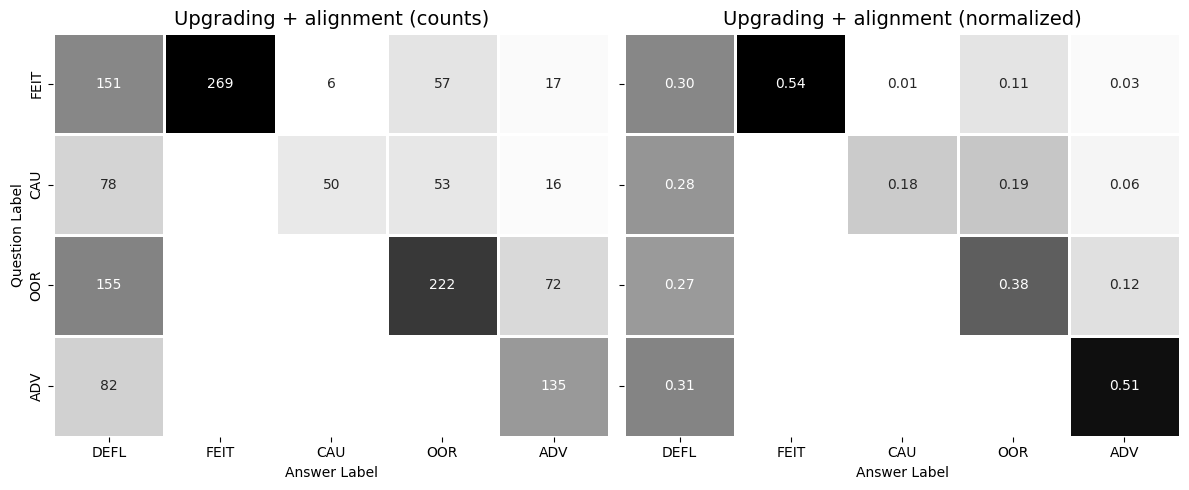

In [14]:
# ---- HIERARCHY ----
q_order = ['FEIT', 'CAU', 'OOR', 'ADV']
a_order = ['DEFL', 'FEIT', 'CAU', 'OOR', 'ADV']

# ---- ENFORCE ORDER ----
df = df.copy()

df["q_label"] = pd.Categorical(df["q_label"], categories=q_order, ordered=True)
df["a_label"] = pd.Categorical(df["a_label"], categories=a_order, ordered=True)

# ---- CROSSTABS ----
ct = pd.crosstab(df["q_label"], df["a_label"]).reindex(index=q_order, columns=a_order)

ct_norm = pd.crosstab(df["q_label"], df["a_label"], normalize='index') \
            .reindex(index=q_order, columns=a_order)

# =========================
# 1) TRIANGLE MASK VERSION
# =========================

# mask "downgrading" region (below diagonal, ignoring DEFL col)
mask = np.zeros_like(ct, dtype=bool)

for i in range(len(q_order)):
    for j in range(len(a_order)):
        # skip DEFL column (j==0)
        if j > 0 and (j-1) < i:   # shift by 1 because DEFL shifts columns
            mask[i, j] = True

f, ax = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True)

sns.heatmap(ct,
            mask=mask,
            cmap='Greys',
            annot=True, fmt='g',
            cbar=False,
            linewidths=1, linecolor='white',
            ax=ax[0])

sns.heatmap(ct_norm,
            mask=mask,
            cmap='Greys',
            annot=True, fmt='.02f',
            cbar=False,
            linewidths=1, linecolor='white',
            ax=ax[1])

ax[0].set_title("Upgrading + alignment (counts)", fontsize=14)
ax[1].set_title("Upgrading + alignment (normalized)", fontsize=14)

ax[0].set_ylabel("Question Label")
ax[0].set_xlabel("Answer Label")
ax[1].set_xlabel("Answer Label")
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [20]:
ct_norm

a_label,DEFL,FEIT,CAU,OOR,ADV
q_label,,,,,
FEIT,0.302000,0.538000,0.012000,0.114000,0.034000
CAU,0.275618,0.303887,0.176678,0.187279,0.056537
OOR,0.267241,0.200000,0.025862,0.382759,0.124138
ADV,0.309434,0.075472,0.007547,0.098113,0.509434


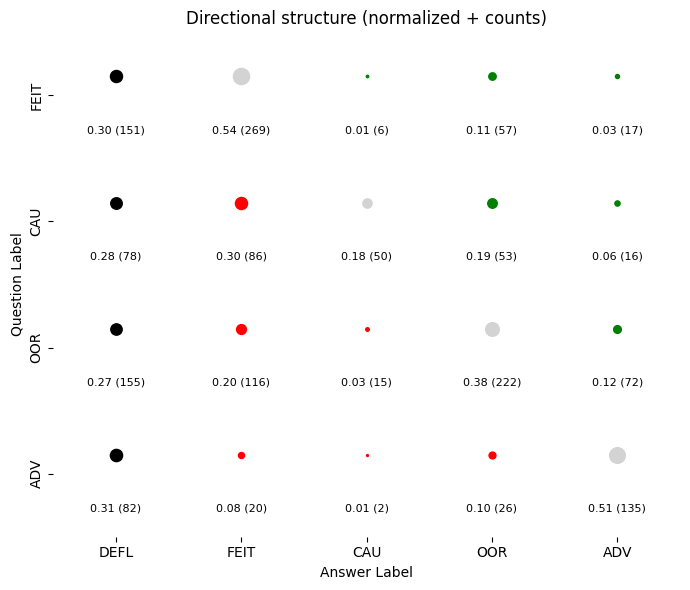

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# base heatmap (normalized only)
sns.heatmap(
    ct_norm,
    cmap="Greys",
    annot=False,
    cbar=False,
    linewidths=25,
    linecolor="white",
    ax=ax,
    vmin=0,
    vmax=0
)

# overlay symbols + values
for i in range(len(q_order)):
    for j in range(len(a_order)):

        norm_val = ct_norm.iloc[i, j]
        abs_val = ct.iloc[i, j]

        # direction logic
        if j == 0:
            symbol = "×"
            color = "black"
        else:
            if (j - 1) > i:
                symbol = "↑"
                color = "green"
            elif (j - 1) < i:
                symbol = "↓"
                color = "red"
            else:
                symbol = "•"
                color = "black"

        # size proportional to normalized value
        size = 250 * norm_val

        # top: symbol (scaled)
        # ax.text(
        #     j + 0.5, i + 0.35,
        #     symbol,
        #     ha="center", va="center",
        #     color=color,
        #     fontsize=size,
        #     fontweight="bold"
        # )
        ax.scatter(j + 0.5, i + 0.35,color="lightgrey" if symbol=='•' else color,s=size)

        # bottom: normalized + absolute
        ax.text(
            j + 0.5, i + 0.78,
            f"{norm_val:.2f} ({abs_val:g})",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

ax.set_title("Directional structure (normalized + counts)")
ax.set_xlabel("Answer Label")
ax.set_ylabel("Question Label")

plt.tight_layout()
plt.show()

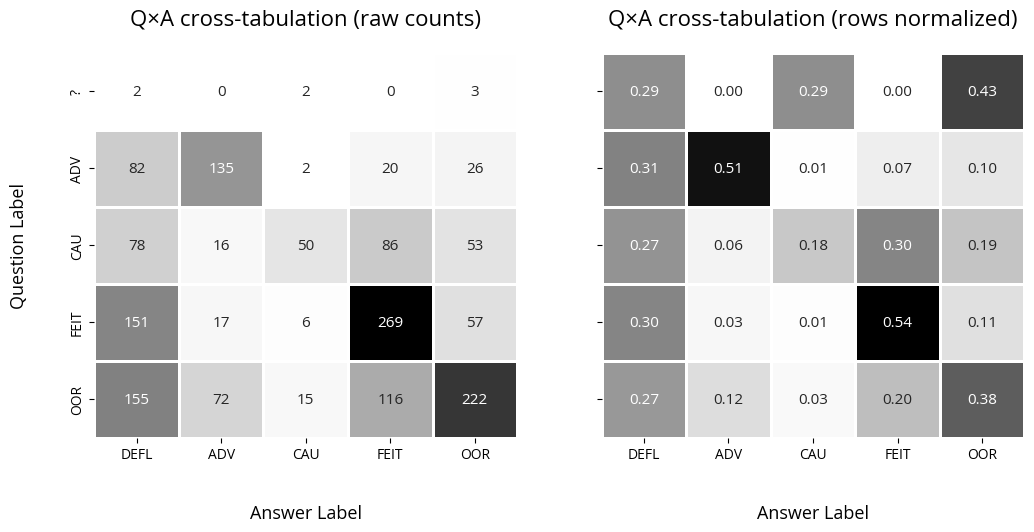

In [53]:
f,a = plt.subplots(1,2,figsize=(12,5), sharex=True, sharey=True)

ct = pd.crosstab(df["q_label"], df["a_label"])
ct = ct[['DEFL','ADV','CAU','FEIT','OOR']]
sns.heatmap(ct,cmap='Greys', annot=True, fmt='g', annot_kws={"fontsize":11}, cbar=False, ax=a[0],
            linecolor='white', linewidths=1)

ct = pd.crosstab(df["q_label"], df["a_label"], normalize='index')
ct = ct[['DEFL','ADV','CAU','FEIT','OOR']]
sns.heatmap(ct,cmap='Greys', annot=True, fmt='.02f', annot_kws={"fontsize":11}, cbar=False, ax=a[1],
            linecolor='white', linewidths=1)

a[1].set_ylabel('')
a[0].set_ylabel('Question Label', labelpad=30, fontweight='bold', fontsize=13)
a[0].set_xlabel('Answer Label', labelpad=30, fontweight='bold', fontsize=13)
a[1].set_xlabel('Answer Label', labelpad=30, fontweight='bold', fontsize=13)

a[0].set_title('Q×A cross-tabulation (raw counts)', fontsize=16, y=1.05)
a[1].set_title('Q×A cross-tabulation (rows normalized)', fontsize=16,  y=1.05)

plt.savefig('figures/cross-tab.png',dpi=250,bbox_inches='tight')
plt.show()

In [34]:
df[(df.a_label=='DEFL') & (df.a_confidence == 'H')][['antwoord']]

,antwoord
3,Wij kennen de overwegingen van de provincies F...
7,"Nee, dit onderwerp maakte geen deel uit van on..."
12,Wij hebben geen onderzoek gedaan naar de gevol...
15,De achtergrond van de verschillen in de financ...
16,De achtergrond van de verschillen in de financ...
...,...
1742,De verslagen die de minister van Financiën naa...
1749,Eurostat heeft tot nu toe geen vergelijkbare i...
1759,Het eerste jaarverslag van het ESM-auditcomité...
1776,Voor onze bevindingen bij alle 23 begrotingsho...


In [36]:
df.antwoord[1777]

'De minister van Financiën stelt in haar reactie op de Staat van de rijksverantwoording 2021 dat zij het financieel beheer verder op orde wil brengen, zodat een toename van meer structurele onrechtmatigheden wordt voorkomen. Zij zal zich hiervoor inzetten en haar collega-ministers verzoeken hetzelfde te doen. Het is aan het parlement om op basis van de jaarverslagen en onze rapporten te bespreken tot welke concrete maatregelen dat leidt en waar nodig bewindslieden aan te sporen.'

In [6]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 2.999312497001893
p-value: 0.999830694129949
Degrees of freedom: 16


In [7]:
import numpy as np

n = ct.sum().sum()
phi2 = chi2 / n
r, k = ct.shape
cramers_v = np.sqrt(phi2 / min(k-1, r-1))

print("Cramér's V:", cramers_v)

Cramér's V: 0.38788397612633935


In [8]:
# !pip install prince

In [9]:
import prince

ca = prince.CA(n_components=2)
ca = ca.fit(ct)

row_coords = ca.row_coordinates(ct)
col_coords = ca.column_coordinates(ct)

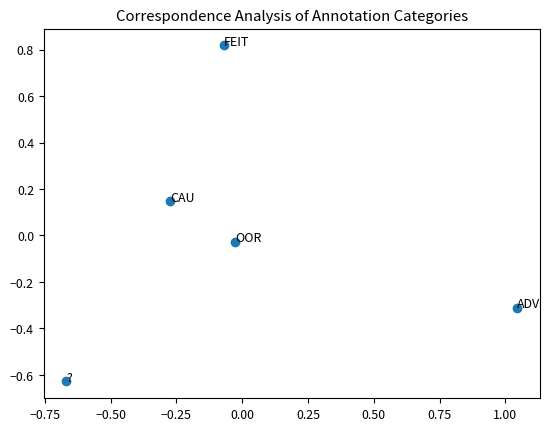

In [10]:
plt.scatter(row_coords[0], row_coords[1])

for i, txt in enumerate(row_coords.index):
    plt.annotate(txt, (row_coords.iloc[i,0], row_coords.iloc[i,1]))

plt.title("Correspondence Analysis of Annotation Categories")
plt.show()

/tmp/ipykernel_225760/3252681678.py:78: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


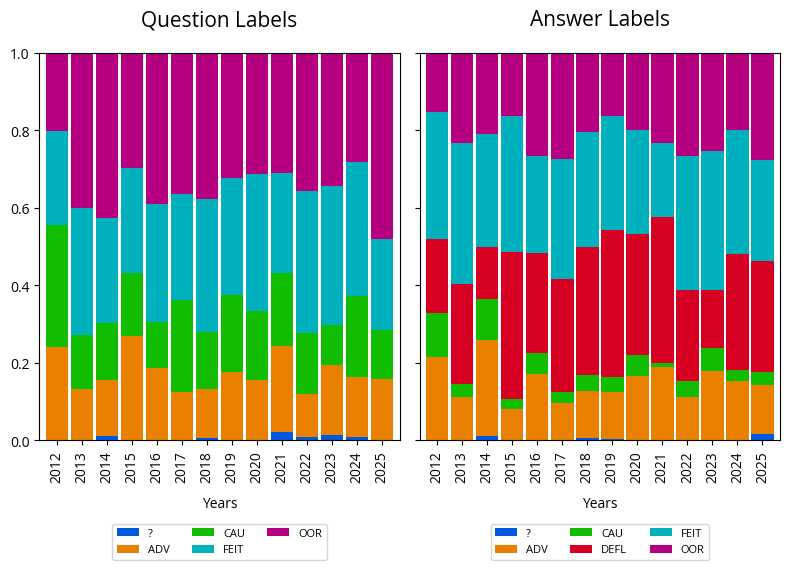

In [54]:
fig, a = plt.subplots(1, 2, figsize=(8, 6), sharex=True, sharey=True, constrained_layout=True)

# Prepare data
q_data = (
    df.groupby(pd.to_datetime(df.src_published_at).dt.year.astype(int))
    .apply(lambda g: g.q_label.value_counts(normalize=True))
    .unstack()
    .fillna(0)
)

a_data = (
    df.groupby(pd.to_datetime(df.src_published_at).dt.year.astype(int))
    .apply(lambda g: g.a_label.value_counts(normalize=True))
    .unstack()
    .fillna(0)
)

# Build global label set for consistent colors
all_labels = sorted(set(q_data.columns).union(set(a_data.columns)))
colors = ['#005ae0','#EA8000', '#12bC00','#D70022','#00B0Bd','#B5007F']

color_map = {label: colors[i % len(colors)] for i, label in enumerate(all_labels)}

# ---- Plot Q labels ----
q_cols = q_data.columns
q_data.plot(
    kind='bar',
    stacked=True,
    ax=a[0],
    color=[color_map[c] for c in q_cols],
    width=.9
)

a[0].set_title("Question Labels", y=1.05, family='Open Sans', fontsize=15)
a[0].set_xlabel("Years", labelpad=10)

handles_q, labels_q = a[0].get_legend_handles_labels()
a[0].legend(
    handles_q,
    labels_q,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    frameon=True,
    fontsize=8
)

# ---- Plot A labels ----
a_cols = a_data.columns
a_data.plot(
    kind='bar',
    stacked=True,
    ax=a[1],
    color=[color_map[c] for c in a_cols],
    width=.9,
    linewidth=.1
)

a[1].set_title("Answer Labels", family='Open Sans', fontsize=15, y=1.05)

handles_a, labels_a = a[1].get_legend_handles_labels()
a[1].legend(
    handles_a,
    labels_a,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    frameon=True,
    fontsize=8
)

a[0].set_ylim(0,1)
a[1].set_ylim(0,1)

a[1].set_xlabel("Years", labelpad=10)

# Optional: prevent overlap and give room for legends
fig.tight_layout()
fig.subplots_adjust(bottom=0.25)
plt.savefig('figures/temporal.png',dpi=250,bbox_inches='tight')

plt.show()

In [48]:
dfm = pd.read_csv('/home/rb/Documents/Code/Rekenkamer/results/kamervragen-metadata.csv', sep='\t', usecols=['src_id', 'commissie'])

In [49]:
dfm['commissie'] = dfm.commissie.str.lower()
dfm = dfm.dropna(subset=['commissie'])
dfm['commissie'] = dfm.commissie.astype(str).apply(lambda x: "financien" if "fina" in x or "rijksui" in x else x)

In [50]:
commissie_mapper = dict(zip(dfm.src_id, dfm.commissie))

In [51]:
df['c'] = dfm.src_id.map(commissie_mapper)

In [64]:
df.c.value_counts()

c
financien                                                                49
vaste commissie voor defensie                                            19
vaste commissie voor binnenlandse zaken                                  16
vaste commissie voor volksgezondheid, welzijn en sport                    8
vaste commissie voor infrastructuur en waterstaat                         7
vaste commissie voor sociale zaken en werkgelegenheid                     6
vaste commissie voor justitie en veiligheid                               6
vaste commissie voor onderwijs, cultuur en wetenschap                     6
vaste commissie voor economische zaken en klimaat                         5
vaste commissie voor veiligheid en justitie                               4
vaste commissie voor koninkrijksrelaties                                  4
vaste commissie voor economische zaken                                    4
vaste commissie voor landbouw, natuur en voedselkwaliteit                 4
vaste comm

In [60]:
dfc = df[df.c.map(df.groupby('c').size()) > 10].dropna(subset="c")

<Axes: xlabel='q_label', ylabel='c'>

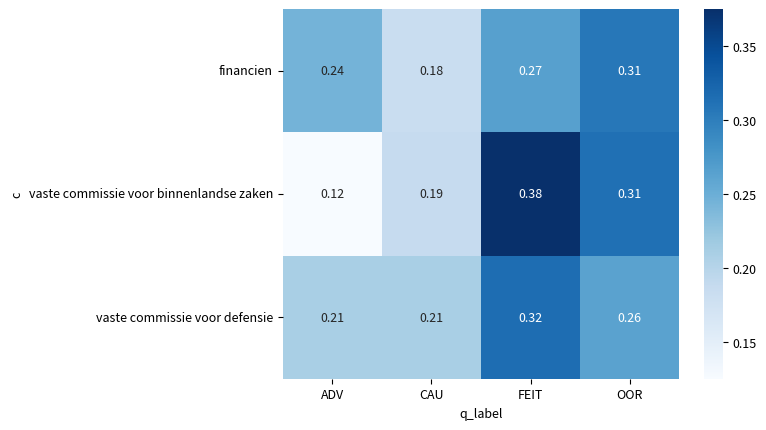

In [62]:
sns.heatmap(pd.crosstab(dfc['c'], dfc['q_label'], normalize='index'), annot=True, cmap='Blues',fmt='.2f')

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from pySankey.sankey import sankey

def plot_pysankey(df, source_col, target_col):
    ct = pd.crosstab(df[source_col], df[target_col], normalize='index')

    links = ct.stack().reset_index()
    links.columns = ["source", "target", "value"]
    links = links[links.value > 0]

    sankey(
        left=links["source"],
        right=links["target"],
        leftWeight=links["value"],
        rightWeight=links["value"]
    )

    plt.title("Sankey Diagram")
    plt.show()

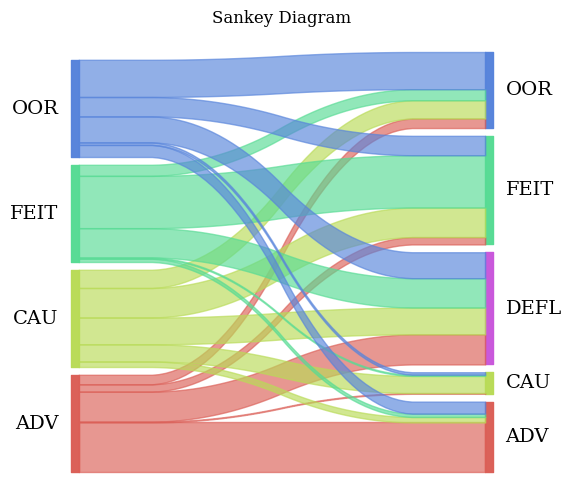

In [76]:
plot_pysankey(df[(df.q_label!='?') & (df.a_label!='?')], 'q_label', 'a_label')

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hierarchical_flows_matplotlib(df, source_col, target_col):

    hierarchy = ["DEFL", "FEIT", "CAU", "OOR", "ADV"]
    level_map = {k: i for i, k in enumerate(hierarchy)}

    # Crosstab (counts, not normalized for visibility)
    ct = pd.crosstab(df[source_col], df[target_col])

    # Ensure all categories exist
    ct = ct.reindex(index=hierarchy, columns=hierarchy, fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Vertical positions for each level
    y_positions = {label: i for i, label in enumerate(hierarchy)}

    # Draw nodes (labels on left and right)
    for label in hierarchy:
        y = y_positions[label]
        ax.text(-0.5, y, label, ha='right', va='center')
        ax.text(1.5, y, label, ha='left', va='center')

    # Draw flows as lines
    for source in hierarchy:
        for target in hierarchy:
            value = ct.loc[source, target]
            if value == 0:
                continue

            y0 = y_positions[source]
            y1 = y_positions[target]

            # thickness scaled
            linewidth = 0.5 + (value / ct.values.max()) * 8

            ax.plot(
                [0, 1],
                [y0, y1],
                linewidth=linewidth,
                alpha=0.6
            )

    # Formatting
    ax.set_xlim(-1, 2)
    ax.set_ylim(-0.5, len(hierarchy) - 0.5)
    ax.set_yticks([])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Questions", "Answers"])
    ax.set_title("Hierarchical Flow (Matplotlib)")

    plt.tight_layout()
    plt.show()

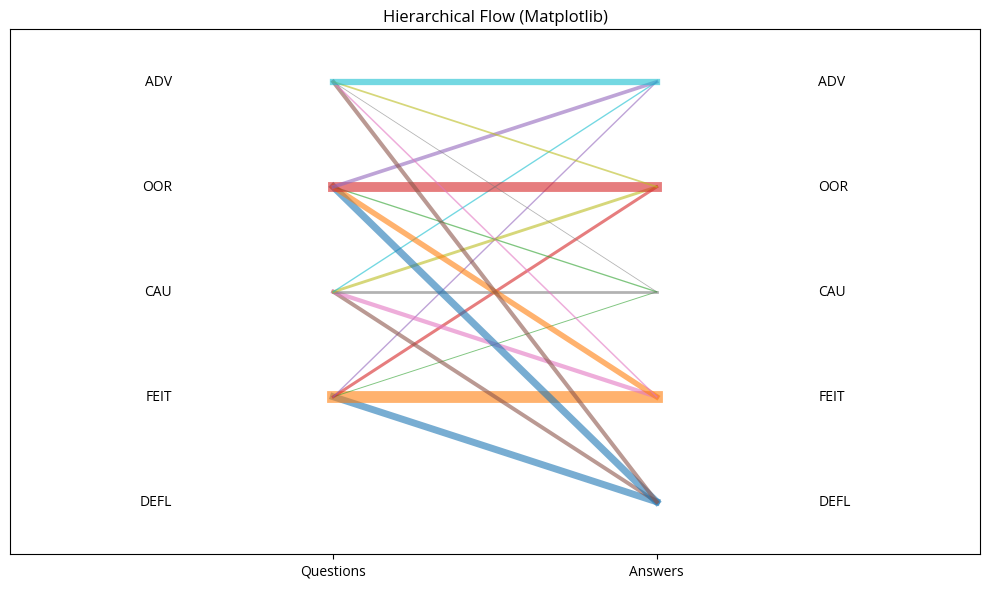

In [79]:
plot_hierarchical_flows_matplotlib(df[(df.q_label!='?') & (df.a_label!='?')], 'q_label', 'a_label')

In [81]:
df[(df.q_label=='OOR') & (df.a_label!='OOR')].a_label.value_counts()

a_label
DEFL    155
FEIT    116
ADV      72
CAU      15
?         1
Name: count, dtype: int64

In [83]:
df[(df.q_label=='OOR') & (df.a_label!='ADV')].antwoord.tolist()

['Wij constateren in ons rapport dat de BJZ/LWI (VWS-)middelen voor de vrijwillige jeugdzorg gebruiken om tekorten op de justitiële taken af te wenden. De aard en de omvang van de financiële resultaten bij de vrijwillige jeugdzorg maakten geen deel uit van ons onderzoek.',
 'Nee, wij kunnen niet aangeven of de schattingen van de BJZ/LWI realistisch zijn. De berekeningen van de BJZ/LWI zijn wel navoigbaar maar onvergelijkbaar, omdat de schattingen zijn gebaseerd op verschillende aannames en berekeningswijzen. Er is te weinig betrouwbare informatie om te bepalen of de normprijzen voor de justitiële maatregelen op het gebied van jeugdbescherming en jeugdreclassering kostendekkend zijn. Uit ons vooronderzoek bleek dat geen enkele BJZ/LWI in staat is een kostprijs te berekenen. Teneinde ordelijk een reële normprijs op basis van de uitvoeringsafspraken te kunnen vaststellen zal geïnvesteerd moeten worden in de administratieve inrichting van de BJZ/LWI. Wij reiken in het rapport een gespecifi